In [11]:
import numpy as np
import pandas as pd
from scipy.stats import poisson

In [29]:
#Data frame for match data
df = pd.DataFrame(matches)
print(df)

#Aggregate xG values for each shot taken by Team A and Team B using the dataframe
team_A_xG = df[df['team'] == 'Team A']['team_xG'].iloc[0]
team_B_xG = df[df['team'] == 'Team B']['team_xG'].iloc[0]

print(f"Team A Total xG: {team_A_xG}")
print(f"Team B Total xG: {team_B_xG}")

     team  team_xG  opponent_xG
0  Team A      1.5          1.0
1  Team B      0.8          1.2
2  Team C      2.0          0.5
Team A Total xG: 1.5
Team B Total xG: 0.8


In [27]:
# Vectorized or row-wise function that can be applied to your entire season history.
season_df = pd.DataFrame(season_data)
season_df[['expected_points', 'P_win', 'P_draw', 'P_loss']] = season_df.apply(
    lambda row: calculate_expected_points_from_xG(row['team_xG'], row['opp_xG']),
    axis=1,
    result_type='expand'
)
print(season_df)

   match_id    team  team_xG  opp_xG  goals_for  goals_against  \
0         1  Team A      1.5     1.0          2              1   
1         2  Team A      0.8     1.2          0              1   
2         3  Team A      2.1     0.5          1              1   

   expected_points     P_win    P_draw    P_loss  
0         1.723683  0.487945  0.259847  0.252207  
1         1.038204  0.246077  0.299972  0.453951  
2         2.422553  0.749089  0.175284  0.075613  


##Determine Match Outcome Probabilities
Create a matrix representing the probabilities of all possible scorelines.


In [5]:
match_probs = np.outer(team_A_goal_probs, team_B_goal_probs)
# Each cell (i, j) in match_probs represents the probability of Team A scoring i goals and Team B scoring j goals.
# Calculate the probabilities of Team A winning, drawing, and losing:
# Probability of Team A winning (Team A scores more than Team B)
P_win = np.sum(np.tril(match_probs, -1))

# Probability of a draw (both teams score the same number of goals)
P_draw = np.sum(np.diag(match_probs))

# Probability of Team A losing (Team A scores fewer goals than Team B)
P_loss = np.sum(np.triu(match_probs, 1))

print(f"Probability of Win: {P_win:.4f}")
print(f"Probability of Draw: {P_draw:.4f}")
print(f"Probability of Loss: {P_loss:.4f}")

Probability of Win: 0.3371
Probability of Draw: 0.5475
Probability of Loss: 0.1153


## Analyze Performance in Tied Games

In [30]:
def calculate_actual_points(row):
    if row['goals_for'] > row['goals_against']:
        return 3 # Win
    elif row['goals_for'] == row['goals_against']:
        return 1 # Draw
    else:
        return 0 # Loss

season_df['actual_points'] = season_df.apply(calculate_actual_points, axis=1)

# Filter for games that ended in a draw (actual_points = 1)
drawn_games_df = season_df[season_df['actual_points'] == 1]

if not drawn_games_df.empty:
    print("Analysis of Drawn Games:")
    display(drawn_games_df[['match_id', 'team_xG', 'opp_xG', 'goals_for', 'goals_against', 'expected_points', 'actual_points']])
    print(f"\nAverage Expected Points in Drawn Games: {drawn_games_df['expected_points'].mean():.2f}")
    print(f"Average Actual Points in Drawn Games: {drawn_games_df['actual_points'].mean():.2f}")
else:
    print("No drawn games found in the season data.")

Analysis of Drawn Games:


,match_id,team_xG,opp_xG,goals_for,goals_against,expected_points,actual_points
2,3,2.1,0.5,1,1,2.422553,1



Average Expected Points in Drawn Games: 2.42
Average Actual Points in Drawn Games: 1.00


##Expected Points


In [6]:
expected_points = (3 * P_win) + (1 * P_draw)
print(f"Expected Points: {expected_points:.2f}")

Expected Points: 1.56


##Apply to Multiple Matches

In [10]:
matches = [
    {'team': 'Team A', 'team_xG': 1.5, 'opponent_xG': 1.0},
    {'team': 'Team B', 'team_xG': 0.8, 'opponent_xG': 1.2},
    {'team': 'Team C', 'team_xG': 2.0, 'opponent_xG': 0.5}
]

def calculate_expected_points_from_xG(team_xG, opponent_xG, max_goals=10):
    # Goal probabilities for the team
    team_goal_probs = [poisson.pmf(i, team_xG) for i in range(max_goals + 1)]
    # Goal probabilities for the opponent
    opponent_goal_probs = [poisson.pmf(i, opponent_xG) for i in range(max_goals + 1)]

    # Matrix of match probabilities
    match_probs = np.outer(team_goal_probs, opponent_goal_probs)

    # Outcome probabilities
    P_win = np.sum(np.tril(match_probs, -1))
    P_draw = np.sum(np.diag(match_probs))
    P_loss = np.sum(np.triu(match_probs, k=1))

    # Expected points calculation
    expected_points = (3 * P_win) + (1 * P_draw)

    return expected_points, P_win, P_draw, P_loss

for match in matches:
    expected_points, P_win, P_draw, P_loss = calculate_expected_points_from_xG(match['team_xG'], match['opponent_xG'])
    print(f"{match['team']} Expected Points: {expected_points:.2f}")

Team A Expected Points: 1.72
Team B Expected Points: 1.04
Team C Expected Points: 2.38


##Model Goal Scoring Probabilities Using Poisson Distribution


In [3]:
# Maximum number of goals to consider
max_goals = 5

# Calculate goal probabilities for Team A and Team B
team_A_goal_probs = [poisson.pmf(i, team_A_xG) for i in range(max_goals + 1)]
team_B_goal_probs = [poisson.pmf(i, team_B_xG) for i in range(max_goals + 1)]

##Goals per Team from Poisson Distribution


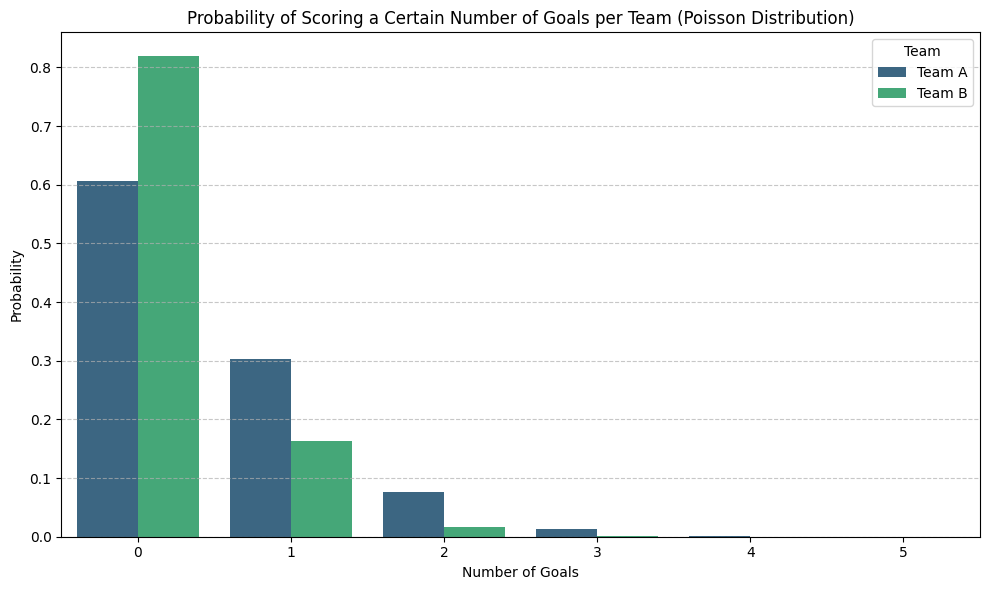

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Number of goals (up to max_goals)
goals = list(range(max_goals + 1))

# Create a DataFrame for easier plotting with seaborn
import pandas as pd

team_A_df = pd.DataFrame({
    'Goals': goals,
    'Probability': team_A_goal_probs,
    'Team': 'Team A'
})
team_B_df = pd.DataFrame({
    'Goals': goals,
    'Probability': team_B_goal_probs,
    'Team': 'Team B'
})

goal_probs_df = pd.concat([team_A_df, team_B_df])

plt.figure(figsize=(10, 6))
sns.barplot(x='Goals', y='Probability', hue='Team', data=goal_probs_df, palette='viridis')
plt.title('Probability of Scoring a Certain Number of Goals per Team (Poisson Distribution)')
plt.xlabel('Number of Goals')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Team')
plt.tight_layout()
plt.show()

##Heatmap of Final Scorelines

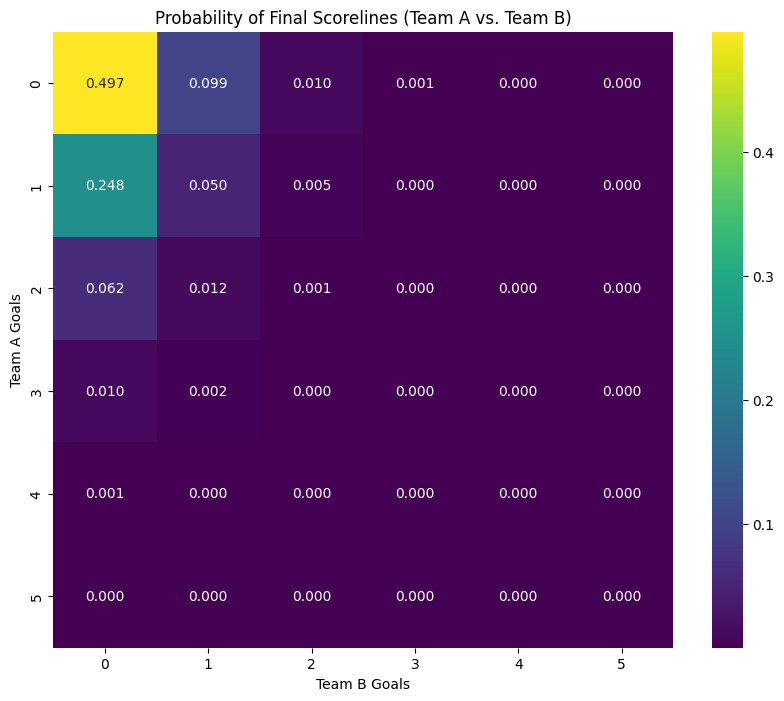

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create labels for the heatmap axes (number of goals)
goal_labels = [str(i) for i in range(max_goals + 1)]

plt.figure(figsize=(10, 8))
sns.heatmap(
    match_probs,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=goal_labels,
    yticklabels=goal_labels
)

plt.title('Probability of Final Scorelines (Team A vs. Team B)')
plt.xlabel('Team B Goals')
plt.ylabel('Team A Goals')
plt.show()

## Visualize Cumulative Performance

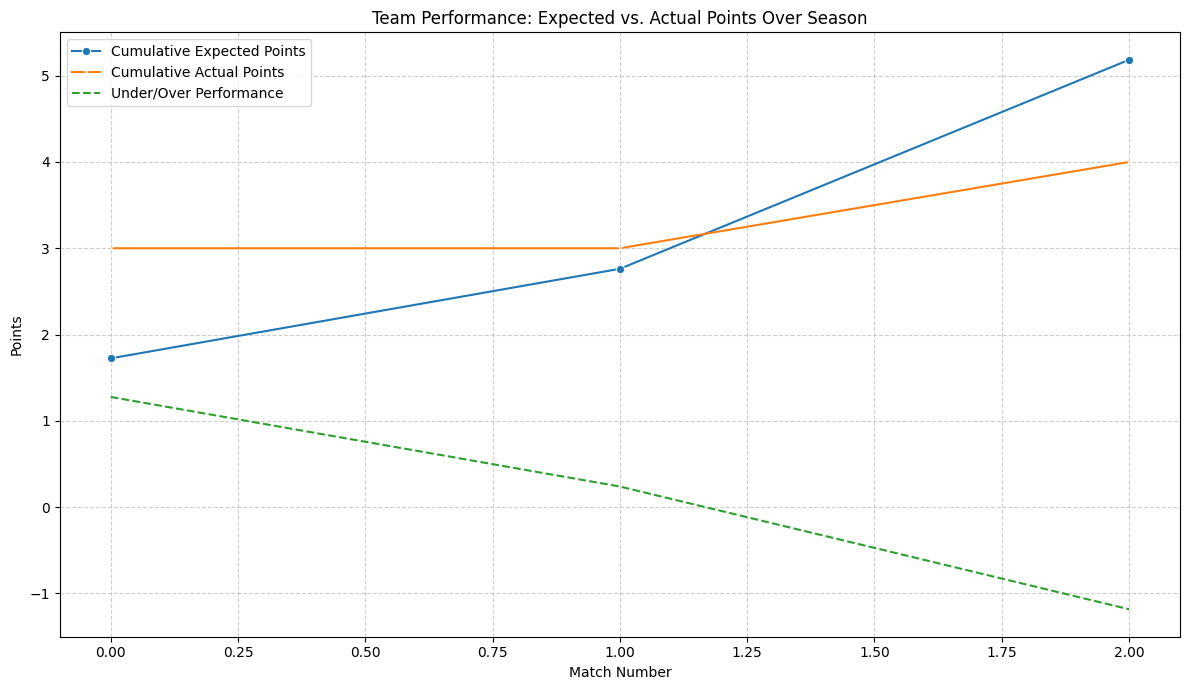

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming season_df is already created and contains the calculated cumulative points

# Calculate actual points for each match
def calculate_actual_points(row):
    if row['goals_for'] > row['goals_against']:
        return 3 # Win
    elif row['goals_for'] == row['goals_against']:
        return 1 # Draw
    else:
        return 0 # Loss

season_df['actual_points'] = season_df.apply(calculate_actual_points, axis=1)

# Calculate cumulative expected points
season_df['cumulative_expected_points'] = season_df['expected_points'].cumsum()

# Calculate cumulative actual points
season_df['cumulative_actual_points'] = season_df['actual_points'].cumsum()

# Calculate 'Under/Over' performance
season_df['under_over_performance'] = season_df['cumulative_actual_points'] - season_df['cumulative_expected_points']

plt.figure(figsize=(12, 7))
sns.lineplot(x=season_df.index, y='cumulative_expected_points', data=season_df, label='Cumulative Expected Points', marker='o')
sns.lineplot(x=season_df.index, y='cumulative_actual_points', data=season_df, label='Cumulative Actual Points', marker='x')
sns.lineplot(x=season_df.index, y='under_over_performance', data=season_df, label='Under/Over Performance', linestyle='--')

plt.title('Team Performance: Expected vs. Actual Points Over Season')
plt.xlabel('Match Number')
plt.ylabel('Points')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()